# Table of Contents
- [Helpers](#helpers-for-readingcleaningevaluation-of-metrics)
- [Model](#cnn-rnn-model-defination)
- [Regularization Functions](#helpers-for-regularization)
- [Training and Metrics](#training-block-with-metric-result)
- [Detection of Outliers](#detecting-outliers)
- [Displaying of Outliers](#displaying-outliers)

In [1]:
import os, random
import pandas as pd

from torch.utils.data import Subset
import numpy as np

from PIL import Image
Image.MAX_IMAGE_PIXELS = None
from PIL import ImageFile, UnidentifiedImageError
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from torchvision.models import resnet50, ResNet50_Weights

import numpy as np
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report

INPUT_DIR = "/kaggle/input/datasets/karvysingh/wikiart"
INPUT_DIR_2 = "/kaggle/input/datasets/karvysingh/trainvalfull"
IMAGES_ROOT = os.path.join(INPUT_DIR, "wikiart_clean", "wikiart")
TRAIN_CSV = os.path.join(INPUT_DIR_2, "style_train_clean.csv")
VAL_CSV   = os.path.join(INPUT_DIR_2, "style_val_clean.csv")

style_names = {}
with open(os.path.join(INPUT_DIR_2, "style_class.txt"), "r") as f:
    for line in f:
        parts = line.strip().split(None, 1)  # split on first whitespace
        style_names[int(parts[0])] = parts[1]

# Helpers for Reading/Cleaning/Evaluation of Metrics

In [ ]:
def read_wikiart_csv(path):
    df = pd.read_csv(path)

    # headerless got misread as header
    if len(df.columns) == 2:
        c0, c1 = df.columns[0], df.columns[1]
        if ("/" in str(c0)) and str(c1).strip().isdigit():
            df = pd.read_csv(path, header=None, names=["relpath", "label"])
            df["label"] = df["label"].astype(int)
            return df

    # normal header (strip spaces)
    df.columns = [c.strip() for c in df.columns]

    # guess columns
    path_col = df.columns[0]
    label_col = df.columns[1]
    for c in df.columns:
        lc = c.lower()
        if lc in ["pictures", "picture", "path", "file", "filename", "image"]:
            path_col = c
        if lc in ["class", "label", "target"]:
            label_col = c

    df = df[[path_col, label_col]].rename(columns={path_col:"relpath", label_col:"label"})
    df["label"] = df["label"].astype(int)
    return df


def filter_bad_images(df, images_root):
    good_rows = []
    bad = 0

    for relpath, label in zip(df["relpath"].astype(str).values, df["label"].values):
        fullpath = os.path.join(images_root, relpath)
        try:
            with Image.open(fullpath) as im:
                im.verify()  # verifies file integrity without decoding full image
            good_rows.append((relpath, int(label)))
        except (OSError, UnidentifiedImageError):
            bad += 1

    out = pd.DataFrame(good_rows, columns=["relpath", "label"])
    print(f"Filtered bad images: {bad} removed, {len(out)} remaining")
    return out

def evaluate_metrics(
    model,
    loader,
    device,
    criterion,
    use_amp=True,
    num_classes=None,
    style_names=None,
):
    model.eval()

    all_targets = []
    all_preds = []
    top5_correct = 0
    total = 0
    val_loss_sum = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            pred = logits.argmax(dim=1)
            batch_size = y.size(0)

            total += batch_size
            val_loss_sum += loss.item() * batch_size

            k = min(5, logits.size(1))
            topk = logits.topk(k, dim=1).indices
            top5_correct += (topk == y.unsqueeze(1)).any(dim=1).sum().item()

            all_targets.extend(y.cpu().numpy())
            all_preds.extend(pred.cpu().numpy())

    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)

    val_loss = val_loss_sum / max(1, total)
    top1 = 100.0 * (all_preds == all_targets).mean()
    top5 = 100.0 * top5_correct / max(1, total)
    macro_f1 = 100.0 * f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = 100.0 * f1_score(all_targets, all_preds, average="weighted")

    if num_classes is None:
        num_classes = int(max(all_targets.max(), all_preds.max())) + 1

    labels = list(range(num_classes))
    per_class_recall = recall_score(
        all_targets,
        all_preds,
        labels=labels,
        average=None,
        zero_division=0
    )

    if style_names is not None:
        per_class_recall = {
            style_names[i] if i < len(style_names) else f"Class {i}": r
            for i, r in enumerate(per_class_recall)
        }

    cm = confusion_matrix(all_targets, all_preds, labels=labels)

    return {
        "val_loss": val_loss,
        "top1": top1,
        "top5": top5,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "per_class_recall": per_class_recall,
        "confusion_matrix": cm,
        "targets": all_targets,
        "preds": all_preds,
    }

# CNN-RNN Model Defination

In [3]:
class WikiArtDataset(Dataset):
    def __init__(self, df, images_root, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.images_root = images_root
        self.transform = transform
        self.df["fullpath"] = self.df["relpath"].astype(str).apply(lambda p: os.path.join(images_root, p))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["fullpath"]
        label = int(row["label"])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class AttnPool1D(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.w = nn.Linear(d, 1)

    def forward(self, x):
        # x: (B, T, D)
        a = self.w(x).squeeze(-1)                # (B, T)
        a = torch.softmax(a, dim=1).unsqueeze(-1)
        return (x * a).sum(dim=1)                # (B, D)


class ResNet50_RowColBiGRU(nn.Module):
    def __init__(self, num_classes, proj_dim=320, rnn_hidden=256, dropout=0.4):
        super().__init__()

        base = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.stem = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.proj = nn.Sequential(
            nn.Conv2d(2048, proj_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(proj_dim),
            nn.ReLU(inplace=True),
        )

        self.row_gru = nn.GRU(
            input_size=proj_dim,
            hidden_size=rnn_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2,
        )

        self.col_gru = nn.GRU(
            input_size=proj_dim,
            hidden_size=rnn_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2,
        )

        self.row_pool = AttnPool1D(2 * rnn_hidden)
        self.col_pool = AttnPool1D(2 * rnn_hidden)

        self.dropout = nn.Dropout(dropout)

        fusion_dim = 2048 + (2 * rnn_hidden) + (2 * rnn_hidden)
        self.head = nn.Linear(fusion_dim, num_classes)

    def forward(self, x):
        # f: (B, 2048, H, W)
        f = self.stem(x)

        # global cnn descriptor
        gap = self.gap(f).flatten(1)   # (B, 2048)

        # projected feature map
        z = self.proj(f)               # (B, C, H, W)
        B, C, H, W = z.shape

        # row-wise recurrent modeling
        # (B, C, H, W) -> (B*H, W, C)
        row_seq = z.permute(0, 2, 3, 1).contiguous().view(B * H, W, C)
        row_out, _ = self.row_gru(row_seq)                     # (B*H, W, 2h)
        row_vec = row_out.mean(dim=1).view(B, H, -1)          # (B, H, 2h)
        row_vec = self.row_pool(row_vec)                      # (B, 2h)

        # column-wise recurrent modeling
        # (B, C, H, W) -> (B*W, H, C)
        col_seq = z.permute(0, 3, 2, 1).contiguous().view(B * W, H, C)
        col_out, _ = self.col_gru(col_seq)                    # (B*W, H, 2h)
        col_vec = col_out.mean(dim=1).view(B, W, -1)          # (B, W, 2h)
        col_vec = self.col_pool(col_vec)                      # (B, 2h)

        fused = torch.cat([gap, row_vec, col_vec], dim=1)
        fused = self.dropout(fused)

        return self.head(fused)

# Helpers for Regularization

In [4]:
import math
import numpy as np
import torch
import torch.nn as nn

def rand_bbox(size, lam):
    # size: (B, C, H, W)
    H = size[2]
    W = size[3]

    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    return x1, y1, x2, y2


def apply_mixup(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)

    mixed_x = lam * x + (1.0 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def apply_cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)

    y_a, y_b = y, y[index]

    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x_cut = x.clone()
    x_cut[:, :, x1:x2, y1:y2] = x[index, :, x1:x2, y1:y2]

    box_area = max(0, x2 - x1) * max(0, y2 - y1)
    lam = 1.0 - box_area / float(x.size(2) * x.size(3))

    return x_cut, y_a, y_b, lam


def mixed_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


def maybe_apply_mix(x, y, p_mixup=0.35, p_cutmix=0.35, mixup_alpha=0.3, cutmix_alpha=1.0):
    r = np.random.rand()

    if r < p_mixup:
        x, y_a, y_b, lam = apply_mixup(x, y, alpha=mixup_alpha)
        return x, y_a, y_b, lam, "mixup"

    if r < p_mixup + p_cutmix:
        x, y_a, y_b, lam = apply_cutmix(x, y, alpha=cutmix_alpha)
        return x, y_a, y_b, lam, "cutmix"

    return x, y, y, 1.0, "none"

from collections import Counter
from torch.utils.data import WeightedRandomSampler

def make_weighted_sampler(labels):
    counts = Counter(labels)
    class_weights = {cls: 1.0 / count for cls, count in counts.items()}
    sample_weights = [class_weights[int(y)] for y in labels]
    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

def build_optimizer(model):
    head_params = []
    for name in ["proj", "row_gru", "col_gru", "row_pool", "col_pool", "head"]:
        head_params += list(getattr(model, name).parameters())

    backbone_params = [p for p in model.stem.parameters() if p.requires_grad]
    head_params = [p for p in head_params if p.requires_grad]

    optimizer = optim.AdamW(
        [
            {"params": head_params, "lr": 8e-4, "weight_decay": 1e-4},
            {"params": backbone_params, "lr": 1.5e-4, "weight_decay": 1e-4},
        ]
    )
    return optimizer

# Training Block with Metric Result

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_df = read_wikiart_csv(TRAIN_CSV)
train_df = filter_bad_images(train_df, IMAGES_ROOT)
val_df = read_wikiart_csv(VAL_CSV)

num_classes = int(max(train_df["label"].max(), val_df["label"].max())) + 1
print("num_classes:", num_classes)
print("train/val sizes:", len(train_df), len(val_df))

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(384, scale=(0.7, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(416),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = WikiArtDataset(train_df, IMAGES_ROOT, transform=train_transform)
val_dataset = WikiArtDataset(val_df, IMAGES_ROOT, transform=val_transform)

train_sampler = make_weighted_sampler(train_df["label"].tolist())

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=train_sampler,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

model = ResNet50_RowColBiGRU(
    num_classes=num_classes,
    proj_dim=320,
    rnn_hidden=256,
    dropout=0.4
).to(device)

for i in range(4):
    set_requires_grad(model.stem[i], False)
for i in range(4, 8):
    set_requires_grad(model.stem[i], True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.03)

use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

head_params = []
for name in ["proj", "row_gru", "col_gru", "row_pool", "col_pool", "head"]:
    head_params += list(getattr(model, name).parameters())

backbone_params = [p for p in model.stem.parameters() if p.requires_grad]
head_params = [p for p in head_params if p.requires_grad]

epochs = 20
best_top1 = -1.0
unfreeze_epoch = 7

optimizer = optim.AdamW(
    [
        {"params": head_params, "lr": 8e-4, "weight_decay": 1e-4},
        {"params": backbone_params, "lr": 1.5e-4, "weight_decay": 1e-4},
    ]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=1e-6
)

for epoch in range(1, epochs + 1):
    if epoch == unfreeze_epoch:
        for p in model.stem.parameters():
            p.requires_grad = True

        optimizer = build_optimizer(model)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs - epoch + 1,
            eta_min=1e-6
        )
        print(f"Unfroze full backbone at epoch {epoch}")
        
    model.train()
    loss_sum = 0.0
    steps = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        x_mixed, y_a, y_b, lam, mix_kind = maybe_apply_mix(
            x, y,
            p_mixup=0.35,
            p_cutmix=0.35,
            mixup_alpha=0.3,
            cutmix_alpha=1.0
        )

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model(x_mixed)

            if mix_kind == "none":
                loss = criterion(logits, y)
            else:
                loss = mixed_criterion(criterion, logits, y_a, y_b, lam)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()
        steps += 1

    scheduler.step()

    metrics = evaluate_metrics(
        model=model,
        loader=val_loader,
        device=device,
        use_amp=use_amp,
        num_classes=num_classes,
        criterion=criterion
    )

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss {loss_sum/max(1, steps):.4f} | "
        f"val_loss {metrics['val_loss']:.4f} | "
        f"val_top1 {metrics['top1']:.2f}% | "
        f"val_top5 {metrics['top5']:.2f}% | "
        f"macro_f1 {metrics['macro_f1']:.2f}% | "
        f"weighted_f1 {metrics['weighted_f1']:.2f}%"
    )

    if metrics["top1"] > best_top1:
        best_top1 = metrics["top1"]
        torch.save(model.state_dict(), "best_style_rowcol_bigru.pt")
        print(f"Saved best checkpoint with top1={best_top1:.2f}%")

best_ckpt = "best_style_rowcol_bigru.pt"
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()
print(f"Loaded best checkpoint: {best_ckpt}")

final_metrics = evaluate_metrics(
    model=model,
    loader=val_loader,
    device=device,
    use_amp=use_amp,
    num_classes=num_classes,
    style_names=style_names,
    criterion=criterion
)

print("\n================ FINAL VALIDATION METRICS ================\n")
print(f"Top-1 Accuracy    : {final_metrics['top1']:.2f}%")
print(f"Top-5 Accuracy    : {final_metrics['top5']:.2f}%")
print(f"Macro F1 Score    : {final_metrics['macro_f1']:.2f}%")
print(f"Weighted F1 Score : {final_metrics['weighted_f1']:.2f}%")

print("\nPer-Class Recall:\n")
for class_name, recall in final_metrics["per_class_recall"].items():
    print(f"{class_name} : {100 * recall:.2f}%")

from sklearn.metrics import classification_report
print("\nClassification Report:\n")
target_names = [style_names[i] for i in sorted(style_names.keys())]

print(
    classification_report(
        final_metrics["targets"],
        final_metrics["preds"],
        labels=list(range(len(target_names))),
        target_names=target_names,
        digits=3,
        zero_division=0
    )
)

from sklearn.metrics import confusion_matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(final_metrics["targets"], final_metrics["preds"]))

Device: cuda
Filtered bad images: 0 removed, 57025 remaining
num_classes: 27
train/val sizes: 57025 24421
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s] 


Epoch 01/20 | train_loss 1.7483 | val_loss 1.7260 | val_top1 47.28% | val_top5 89.71% | macro_f1 48.82% | weighted_f1 48.06%
Saved best checkpoint with top1=47.28%
Epoch 02/20 | train_loss 1.4192 | val_loss 1.6130 | val_top1 51.13% | val_top5 91.72% | macro_f1 53.05% | weighted_f1 50.70%
Saved best checkpoint with top1=51.13%
Epoch 03/20 | train_loss 1.2728 | val_loss 1.4790 | val_top1 56.30% | val_top5 92.87% | macro_f1 56.64% | weighted_f1 56.30%
Saved best checkpoint with top1=56.30%
Epoch 04/20 | train_loss 1.2074 | val_loss 1.4008 | val_top1 58.17% | val_top5 94.34% | macro_f1 59.08% | weighted_f1 57.84%
Saved best checkpoint with top1=58.17%
Epoch 05/20 | train_loss 1.1553 | val_loss 1.3741 | val_top1 59.79% | val_top5 94.30% | macro_f1 60.69% | weighted_f1 59.59%
Saved best checkpoint with top1=59.79%
Epoch 06/20 | train_loss 1.1038 | val_loss 1.3182 | val_top1 61.62% | val_top5 94.84% | macro_f1 62.35% | weighted_f1 61.74%
Saved best checkpoint with top1=61.62%
Unfroze full bac

# Detecting outliers

In [6]:
# ===== Outlier mining on the validation set =====
# Finds paintings that do not fit their assigned style well.

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

@torch.no_grad()
def extract_fused_features(model, x):
    # same feature pipeline as model.forward(), but stops before final classifier head
    f = model.stem(x)

    gap = model.gap(f).flatten(1)

    z = model.proj(f)
    B, C, H, W = z.shape

    row_seq = z.permute(0, 2, 3, 1).contiguous().view(B * H, W, C)
    row_out, _ = model.row_gru(row_seq)
    row_vec = row_out.mean(dim=1).view(B, H, -1)
    row_vec = model.row_pool(row_vec)

    col_seq = z.permute(0, 3, 2, 1).contiguous().view(B * W, H, C)
    col_out, _ = model.col_gru(col_seq)
    col_vec = col_out.mean(dim=1).view(B, W, -1)
    col_vec = model.col_pool(col_vec)

    fused = torch.cat([gap, row_vec, col_vec], dim=1)
    fused = model.dropout(fused)
    return fused

@torch.no_grad()
def build_embedding_table(model, df, images_root, transform, batch_size=64):
    ds = WikiArtDataset(df, images_root, transform=transform)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    model.eval()
    feats_all, labels_all, probs_all, preds_all = [], [], [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        feats = extract_fused_features(model, x)
        feats = F.normalize(feats, dim=1)

        logits = model.head(feats)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        feats_all.append(feats.cpu())
        labels_all.append(y.cpu())
        probs_all.append(probs.cpu())
        preds_all.append(preds.cpu())

    feats_all = torch.cat(feats_all, dim=0)
    labels_all = torch.cat(labels_all, dim=0)
    probs_all = torch.cat(probs_all, dim=0)
    preds_all = torch.cat(preds_all, dim=0)

    out = df.reset_index(drop=True).copy()
    out["true_label"] = labels_all.numpy()
    out["pred_label"] = preds_all.numpy()
    out["true_style"] = out["true_label"].map(style_names)
    out["pred_style"] = out["pred_label"].map(style_names)
    out["pred_conf"] = probs_all.max(dim=1).values.numpy()

    return out, feats_all, labels_all

def score_outliers(df_base, feats, labels):
    labels = labels.long()
    classes = sorted(labels.unique().tolist())

    # class centroids
    centroids = []
    for c in classes:
        mask = labels == c
        cen = feats[mask].mean(dim=0)
        cen = F.normalize(cen.unsqueeze(0), dim=1).squeeze(0)
        centroids.append(cen)
    centroids = torch.stack(centroids)  # [K, D]

    # cosine similarity to all class centroids
    sims = feats @ centroids.T

    idx = torch.arange(len(labels))
    assigned_sim = sims[idx, labels]

    # nearest "wrong" class
    other_sims = sims.clone()
    other_sims[idx, labels] = -1e9
    best_other_sim, best_other_label = other_sims.max(dim=1)

    # distance from own centroid
    outlier_score = 1.0 - assigned_sim

    # smaller margin = more suspicious, negative = closer to another style
    margin = assigned_sim - best_other_sim

    out = df_base.copy()
    out["assigned_sim"] = assigned_sim.numpy()
    out["best_other_sim"] = best_other_sim.numpy()
    out["best_other_label"] = best_other_label.numpy()
    out["best_other_style"] = out["best_other_label"].map(style_names)
    out["outlier_score"] = outlier_score.numpy()
    out["margin"] = margin.numpy()

    # combined ranking: high distance + low margin + prediction mismatch
    out["is_mismatch"] = (out["pred_label"] != out["true_label"]).astype(int)
    out["combined_score"] = out["outlier_score"] - out["margin"] + 0.25 * out["is_mismatch"]

    return out.sort_values(
        ["combined_score", "is_mismatch", "outlier_score", "margin"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

out_base, val_feats, val_labels = build_embedding_table(
    model=model,
    df=val_df,
    images_root=IMAGES_ROOT,
    transform=val_transform,
    batch_size=64
)

outliers_df = score_outliers(out_base, val_feats, val_labels)
outliers_df.to_csv("style_outliers.csv", index=False)

print("Top suspicious paintings:")
display(
    outliers_df.head(30)[[
        "relpath",
        "true_style",
        "pred_style",
        "pred_conf",
        "assigned_sim",
        "best_other_style",
        "best_other_sim",
        "outlier_score",
        "margin",
        "combined_score",
        "is_mismatch",
    ]]
)

Top suspicious paintings:


,relpath,true_style,pred_style,pred_conf,assigned_sim,best_other_style,best_other_sim,outlier_score,margin,combined_score,is_mismatch
0,Naive_Art_Primitivism/viorel-marginean_unknown...,Naive_Art_Primitivism,Pop_Art,0.092451,0.052710,Pop_Art,0.796786,0.947290,-0.744077,1.941367,1
1,Naive_Art_Primitivism/miriam-schapiro_sonia-de...,Naive_Art_Primitivism,Pop_Art,0.083040,0.047747,Pop_Art,0.761725,0.952253,-0.713978,1.916231,1
2,Ukiyo_e/katsushika-hokusai_carp-leaping-up-a-c...,Ukiyo_e,Early_Renaissance,0.078441,0.076674,Early_Renaissance,0.795618,0.923326,-0.718944,1.892270,1
3,Mannerism_Late_Renaissance/jacopo-pontormo_epi...,Mannerism_Late_Renaissance,Early_Renaissance,0.076033,0.100470,Early_Renaissance,0.842492,0.899530,-0.742022,1.891552,1
4,Naive_Art_Primitivism/aldemir-martins_white-ca...,Naive_Art_Primitivism,Pop_Art,0.084519,0.096011,Pop_Art,0.777346,0.903989,-0.681336,1.835325,1
5,Northern_Renaissance/albrecht-durer_man-s-head...,Northern_Renaissance,Early_Renaissance,0.080015,0.129918,Early_Renaissance,0.814013,0.870082,-0.684095,1.804177,1
6,Northern_Renaissance/joachim-wtewael_the-battl...,Northern_Renaissance,Mannerism_Late_Renaissance,0.087198,0.159538,Mannerism_Late_Renaissance,0.864043,0.840462,-0.704505,1.794967,1
7,Naive_Art_Primitivism/fernand-leger_the-album-...,Naive_Art_Primitivism,Pop_Art,0.096023,0.158780,Pop_Art,0.835142,0.841220,-0.676362,1.767582,1
8,Expressionism/abidin-dino_legendes-a-venir-the...,Expressionism,Pop_Art,0.086934,0.129569,Pop_Art,0.771171,0.870431,-0.641602,1.762034,1
9,Naive_Art_Primitivism/marc-chagall_the-exodus-...,Naive_Art_Primitivism,Early_Renaissance,0.071646,0.099350,Early_Renaissance,0.709077,0.900650,-0.609727,1.760377,1


# Displaying Outliers

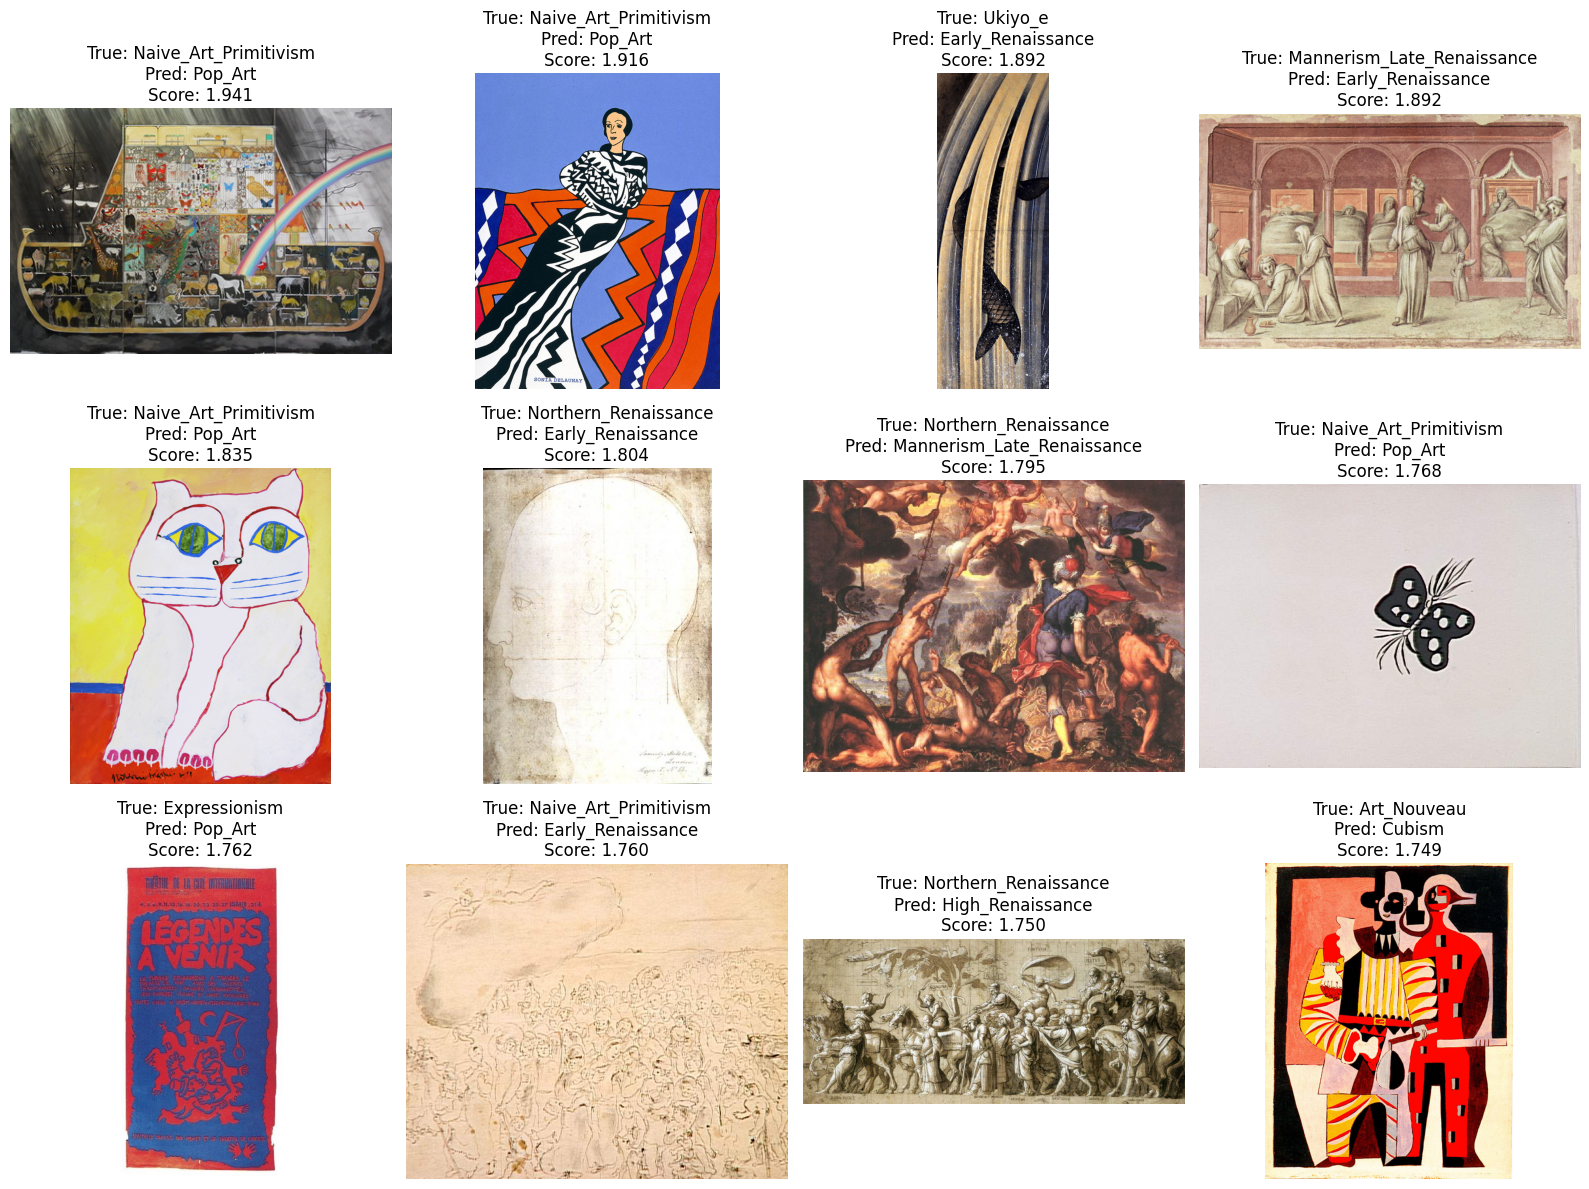

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import os

top_n = 12
rows = outliers_df.head(top_n).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, rows.iterrows()):
    img = Image.open(os.path.join(IMAGES_ROOT, row["relpath"])).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f'True: {row["true_style"]}\n'
        f'Pred: {row["pred_style"]}\n'
        f'Score: {row["combined_score"]:.3f}'
    )
    ax.axis("off")

for ax in axes[len(rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()